#  Analyse and Visualise the Space Race.ipynb

### You've learnt about all the core aspects of data exploration, data cleaning, and data visualisation. Download, unzip and open the notebook I've included for this assignment.

### You'll find an incredibly rich dataset from nextspaceflight.com that includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957! It has data on the mission status (success/failure), the cost of the mission, the number of launches per country, and much much more. There's so much we can learn from this dataset about the dominant organisations and the trends over time. For example:

### - Who launched the most missions in any given year?

### -How has the cost of a space mission varied over time?

### -Which months are the most popular for launches?

### -Have space missions gotten safer or has the chance of failure remained unchanged?

### I'm sure that you'll discover many more questions that you can formulate and answer with this dataset! Use it to practice what you learnt about creating various types of charts and visualisations, from choropleths to sunburst charts to segmented bar charts and see if you can turn data into insight. Good luck!

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_missions=pd.read_csv('mission_launches.csv')
df_missions.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [171]:
df_missions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Organisation    4324 non-null   object
 3   Location        4324 non-null   object
 4   Date            4324 non-null   object
 5   Detail          4324 non-null   object
 6   Rocket_Status   4324 non-null   object
 7   Price           964 non-null    object
 8   Mission_Status  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


In [172]:
print(df_missions['Unnamed: 0'].is_monotonic_increasing)
print(df_missions['Unnamed: 0.1'].is_monotonic_increasing)

True
True


In [173]:
df_missions=df_missions.drop(columns=['Unnamed: 0.1'])
df_missions.head()

,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [174]:
df_missions.rename(columns={'Unnamed: 0': 'Id'}, inplace=True)
df_missions.head()


,Id,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [175]:
df_missions=df_missions.set_index('Id')

In [176]:
df_missions.isna().sum()

Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64

In [177]:
 df_missions['Date'] = pd.to_datetime(df_missions['Date'], errors='coerce')

In [178]:
 df_missions['Price'] = pd.to_numeric(df_missions['Price'], errors='coerce')

In [179]:
df_missions['Mission_Status'] = df_missions['Mission_Status'].astype('category')

In [180]:
df_missions['Rocket_Status'] = df_missions['Rocket_Status'].astype('category')

In [181]:
df_missions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4324 entries, 0 to 4323
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   Organisation    4324 non-null   object             
 1   Location        4324 non-null   object             
 2   Date            4198 non-null   datetime64[ns, UTC]
 3   Detail          4324 non-null   object             
 4   Rocket_Status   4324 non-null   category           
 5   Price           949 non-null    float64            
 6   Mission_Status  4324 non-null   category           
dtypes: category(2), datetime64[ns, UTC](1), float64(1), object(3)
memory usage: 211.5+ KB


In [182]:
print(df_missions['Price'].mean())
print(df_missions['Price'].median())
print(df_missions['Price'].skew()) 
#sesgo a la derecha

129.79523709167546
62.0
1.5077937711635496


In [183]:
df_missions['Price'] = df_missions['Price'].fillna(df_missions['Price'].median())

In [184]:
print(df_missions['Price'].mean())
print(df_missions['Price'].median())
print(df_missions['Price'].skew()) 

76.87920444033304
62.0
4.460606705103812


In [185]:
Q1 = df_missions['Price'].quantile(0.25)
Q3 = df_missions['Price'].quantile(0.75)
IQR = Q3 - Q1

outliers = df_missions[df_missions['Price'] > Q3 + 1.5 * IQR]
print(outliers[['Price']].sort_values('Price', ascending=False))

       Price
Id          
2300  450.00
2323  450.00
2348  450.00
1073  450.00
1076  450.00
...      ...
5      64.68
3971   63.23
3993   63.23
4000   63.23
4020   63.23

[457 rows x 1 columns]


In [186]:
print(df_missions['Price'].value_counts().head(10)) 
print((df_missions['Price'] == 450).sum())           
print(len(df_missions))                              

Price
62.00     3416
450.00     136
200.00      75
40.00       55
30.80       38
109.00      37
64.68       34
50.00       34
29.75       33
90.00       32
Name: count, dtype: int64
136
4324


In [187]:
df_missions[df_missions['Price'] == 450]['Detail'].value_counts()

Detail
Space Shuttle Atlantis | STS-135     1
Space Shuttle Endeavour | STS-134    1
Space Shuttle Discovery | STS-133    1
Space Shuttle Atlantis | STS-132     1
Space Shuttle Discovery | STS-131    1
                                    ..
Space Shuttle Columbia | STS-5       1
Space Shuttle Columbia | STS-4       1
Space Shuttle Columbia | STS-3       1
Space Shuttle Columbia | STS-2       1
Space Shuttle Columbia | STS-1       1
Name: count, Length: 136, dtype: int64

# releases in its entire history

In [188]:
df_missions['Organisation'].value_counts(ascending=False).head(5)

Organisation
RVSN USSR           1777
Arianespace          279
General Dynamics     251
CASC                 251
NASA                 203
Name: count, dtype: int64

# Who launched the most missions in  years?

In [189]:
df_missions['Year'] = df_missions['Date'].dt.year.astype('Int64')
df_launch_year=df_missions.groupby([df_missions['Year'], 'Organisation']).size().reset_index(name='Launch').sort_values(['Year', 'Launch'], ascending=[True, False]).groupby('Year').first().reset_index()
df_launch_year

,Year,Organisation,Launch
0,1957,RVSN USSR,2
1,1958,AMBA,7
2,1959,US Air Force,10
3,1960,US Air Force,21
4,1961,US Air Force,23
...,...,...,...
59,2016,CASC,22
60,2017,SpaceX,18
61,2018,CASC,37
62,2019,CASC,27


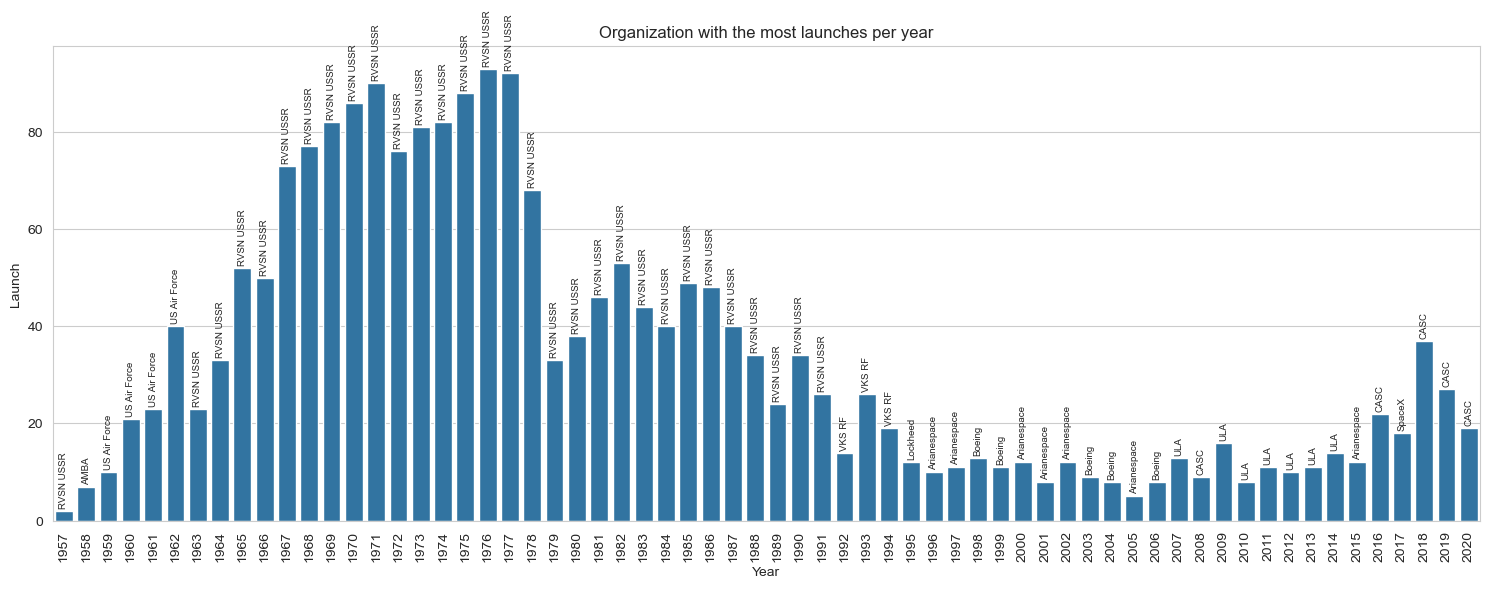

In [190]:
plt.figure(figsize=(15, 6))

ax = sns.barplot(data=df_launch_year, x='Year', y='Launch')


for bar, org in zip(ax.patches, df_launch_year['Organisation']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        org,
        ha='center', va='bottom',
        fontsize=7, rotation=90
    )

plt.title('Organization with the most launches per year')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# How has the cost of a space mission varied over time?

In [191]:
df_organisation_cost=df_missions.groupby(['Year','Organisation'])['Price'].sum().reset_index()
df_organisation_cost

,Year,Organisation,Price
0,1957,RVSN USSR,124.0
1,1957,US Navy,62.0
2,1958,AMBA,434.0
3,1958,NASA,124.0
4,1958,RVSN USSR,310.0
...,...,...,...
627,2020,Roscosmos,210.5
628,2020,SpaceX,712.0
629,2020,ULA,533.0
630,2020,VKS RF,172.5


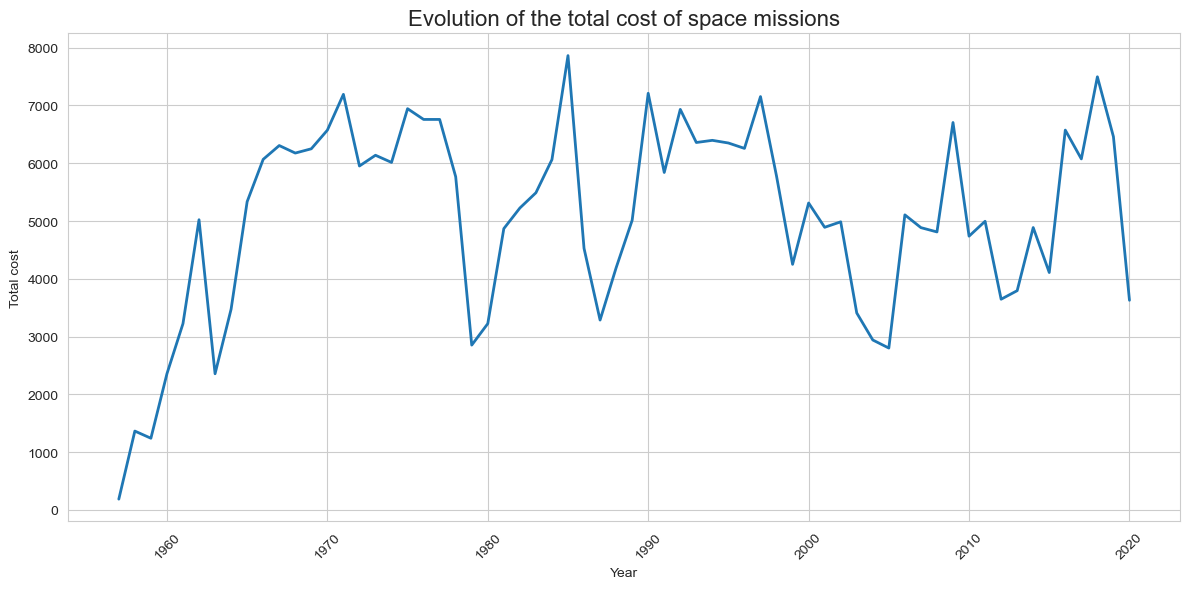

In [192]:
df_year_cost = df_missions.groupby('Year')['Price'].sum().reset_index()
sns.set_style("whitegrid")

plt.figure(figsize=(12,6))
sns.lineplot(data=df_year_cost, x='Year', y='Price', linewidth=2)

plt.title('Evolution of the total cost of space missions', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Total cost')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Which months are the most popular for launches?

In [193]:
df_missions['Month_name'] = df_missions['Date'].dt.month_name()
df_missions['Month'] = df_missions['Date'].dt.month.astype('Int64')

In [194]:

df_month = (
    df_missions
    .groupby(['Month','Month_name'])
    .size()
    .reset_index(name='Launches')
    .sort_values('Launches',ascending=False)
)
df_month


,Month,Month_name,Launches
11,12,December,430
5,6,June,386
9,10,October,375
3,4,April,366
7,8,August,358
8,9,September,354
2,3,March,349
6,7,July,347
10,11,November,325
1,2,February,323


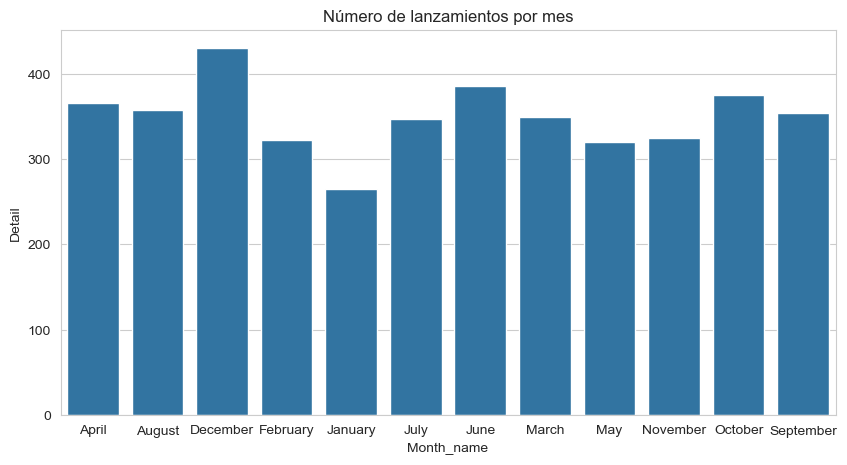

In [195]:
df_month = df_missions['Month_name'].value_counts().sort_index().reset_index()
df_month.columns = ['Month_name', 'Detail']

plt.figure(figsize=(10,5))
sns.barplot(data=df_month, x='Month_name', y='Detail')

plt.title('Número de lanzamientos por mes')
plt.show()

# Have space missions gotten safer or has the chance of failure remained unchanged?

In [196]:

# Probabilidad de Success
(df_missions['Mission_Status'] == 'Success').mean()


np.float64(0.8970860314523589)

In [197]:
# Probabilidad de Fallas
(df_missions['Mission_Status'] == 'Failure').mean()


np.float64(0.07839962997224792)

In [198]:
df_missions['Success'] = (df_missions['Mission_Status'] == 'Success').astype(int)

In [199]:
df_missions['Success']

Id
0       1
1       1
2       1
3       1
4       1
       ..
4319    0
4320    1
4321    0
4322    1
4323    1
Name: Success, Length: 4324, dtype: int64

In [200]:
df_success_year = df_missions.groupby('Year')['Success'].mean().reset_index()
df_success_year

,Year,Success
0,1957,0.666667
1,1958,0.272727
2,1959,0.400000
3,1960,0.500000
4,1961,0.615385
...,...,...
59,2016,0.954545
60,2017,0.922222
61,2018,0.965812
62,2019,0.934579


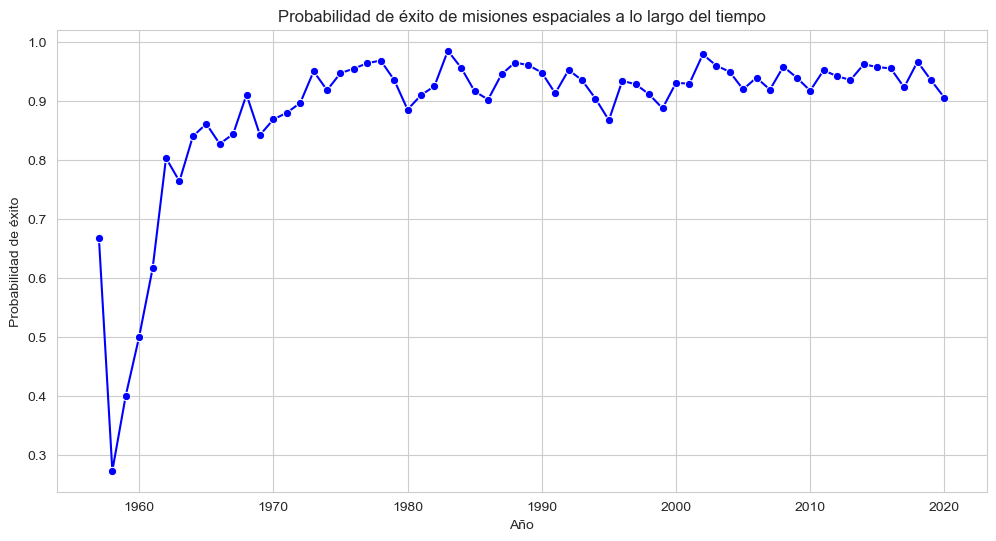

In [201]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_success_year, x='Year', y='Success',marker='o',color='blue')

plt.title('Probabilidad de éxito de misiones espaciales a lo largo del tiempo')
plt.ylabel('Probabilidad de éxito')
plt.xlabel('Año')
plt.show()

In [202]:
df_missions

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Year,Month_name,Month,Success
Id,,,,,,,,,,,
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07 05:12:00+00:00,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success,2020,August,8,1
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00+00:00,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,2020,August,8,1
2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04 23:57:00+00:00,Starship Prototype | 150 Meter Hop,StatusActive,62.00,Success,2020,August,8,1
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30 21:25:00+00:00,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success,2020,July,7,1
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30 11:50:00+00:00,Atlas V 541 | Perseverance,StatusActive,145.00,Success,2020,July,7,1
...,...,...,...,...,...,...,...,...,...,...,...
4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1958-02-05 07:33:00+00:00,Vanguard | Vanguard TV3BU,StatusRetired,62.00,Failure,1958,February,2,0
4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",1958-02-01 03:48:00+00:00,Juno I | Explorer 1,StatusRetired,62.00,Success,1958,February,2,1
4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1957-12-06 16:44:00+00:00,Vanguard | Vanguard TV3,StatusRetired,62.00,Failure,1957,December,12,0
